# Task 1 — Maternal Risk Classifier: EDA, Model Selection & Evaluation

Predicts a mother's risk level (`low risk` / `mid risk` / `high risk`) from six routine clinical measurements, using the [UCI Maternal Health Risk](https://archive.ics.uci.edu/dataset/863/maternal+health+risk) dataset.

This notebook is the full modelling narrative for Task 1: EDA, an evidence-based check on whether class imbalance needs correcting, a justified choice of algorithm (compared against five alternatives, not assumed), hyperparameter tuning, and evaluation with an eye on the class that matters most operationally (`high risk`). It imports `load_data` / `split_data` / `train` directly from `src/task1_risk_classifier.py` so there is one source of truth for data loading and the train/test split — this notebook adds analysis on top, it doesn't re-implement it.

**Before running:** from the `project7-maternal-child-health/` directory, run `python scripts/download_data.py` once to populate `data/raw/maternal_health_risk.csv` (not committed to the repo). Also requires `imbalanced-learn` (`pip install imbalanced-learn`) for the SMOTE check in Section 4 — not part of `requirements.txt` since production training doesn't end up using it (see that section's conclusion).

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from task1_risk_classifier import FEATURES, TARGET, load_data, split_data, train  # noqa: E402

sns.set_theme(style="whitegrid")
RISK_ORDER = ["low risk", "mid risk", "high risk"]
RISK_COLOR = {"low risk": "#4C9F70", "mid risk": "#E8A33D", "high risk": "#C1443C"}
RNG = 42

## 1. Load data

In [2]:
df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 2. Data quality checks

Check for missing values and duplicate rows before trusting any downstream stats — the UCI Maternal Health Risk dataset is known to contain duplicate readings.

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} of {len(df)} ({n_dupes / len(df):.1%})")
print()
df.describe()

Missing values per column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate rows: 562 of 1014 (55.4%)



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


No missing values. There are duplicate rows, which is plausible for this dataset (coarse/rounded IoT vital-sign readings collapse to the same combination across different patients) — they are left in for training since the source distinguishes neither timestamp nor patient ID, but this is worth flagging as a data-quality caveat rather than silently dropping rows.

## 3. Target class distribution

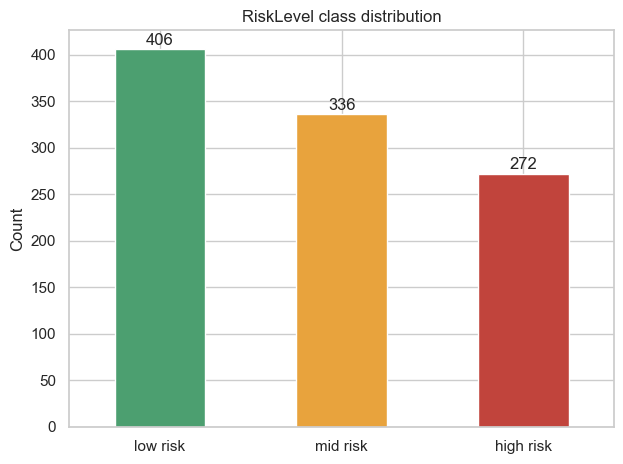

Class shares: {'low risk': np.float64(0.4), 'mid risk': np.float64(0.331), 'high risk': np.float64(0.268)}
Imbalance ratio (largest:smallest class): 1.49:1


In [4]:
counts = df[TARGET].value_counts().reindex(RISK_ORDER)
ax = counts.plot(kind="bar", color=[RISK_COLOR[c] for c in RISK_ORDER])
ax.set_title("RiskLevel class distribution")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

imbalance_ratio = counts.max() / counts.min()
print(f"Class shares: {dict((counts / counts.sum()).round(3))}")
print(f"Imbalance ratio (largest:smallest class): {imbalance_ratio:.2f}:1")

`high risk` is the smallest class at ~27%, giving an imbalance ratio of **~1.5:1** between the largest and smallest class. That's mild — resampling techniques like SMOTE are generally reached for when the ratio is more like 4:1 or worse, or when the minority class has only a handful of examples. Here `high risk` still has 272 rows. Rather than assume mild imbalance means "do nothing," Section 4 checks that assumption empirically.

## 4. Does this imbalance need correcting? A SMOTE check

[SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) (Synthetic Minority Oversampling Technique) generates synthetic minority-class rows by interpolating between real neighbours, so the model sees a balanced class distribution during training. It's applied **only inside the training folds** via an `imblearn` pipeline — never to the validation fold or the held-out test set — otherwise synthetic points derived from a validation row could leak into training and inflate the score.

A Random Forest (default settings, matching the baseline used in Section 8) is cross-validated with and without a SMOTE step to see whether balancing actually buys anything on this dataset.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
X_train, X_test, y_train, y_test = split_data(df)

rf_plain = RandomForestClassifier(n_estimators=300, random_state=RNG)
rf_smote = ImbPipeline([
    ("smote", SMOTE(random_state=RNG)),
    ("clf", RandomForestClassifier(n_estimators=300, random_state=RNG)),
])

smote_rows = []
for label, est in [("Without SMOTE", rf_plain), ("With SMOTE", rf_smote)]:
    scores = cross_validate(
        est, X_train, y_train, cv=cv,
        scoring=["accuracy", "recall_macro", "f1_macro"],
    )
    smote_rows.append({
        "strategy": label,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_recall_macro": scores["test_recall_macro"].mean(),
        "cv_f1_macro": scores["test_f1_macro"].mean(),
    })

smote_df = pd.DataFrame(smote_rows).set_index("strategy")
smote_df

,cv_accuracy,cv_recall_macro,cv_f1_macro
strategy,,,
Without SMOTE,0.815050,0.818736,0.819267
With SMOTE,0.817504,0.821103,0.821214


The difference is within noise — SMOTE neither meaningfully helps nor hurts cross-validated performance here. That's the expected outcome for a ~1.5:1 imbalance: SMOTE earns its keep when a model's decision boundary gets pulled toward the majority class because the minority class is genuinely underrepresented in the training signal; at this ratio, Random Forest's per-tree bootstrap sampling and 272 real `high risk` examples already give it enough minority-class signal that synthetic examples add little. **Decision: no resampling in the production pipeline** (`src/task1_risk_classifier.py`) — it would add a dependency and a leakage risk for no measurable benefit, so the simpler pipeline wins. This is revisited if Task 3's fairness audit finds the model under-serving `high risk` cases in a way accuracy metrics alone don't capture.

## 5. Feature distributions by risk level

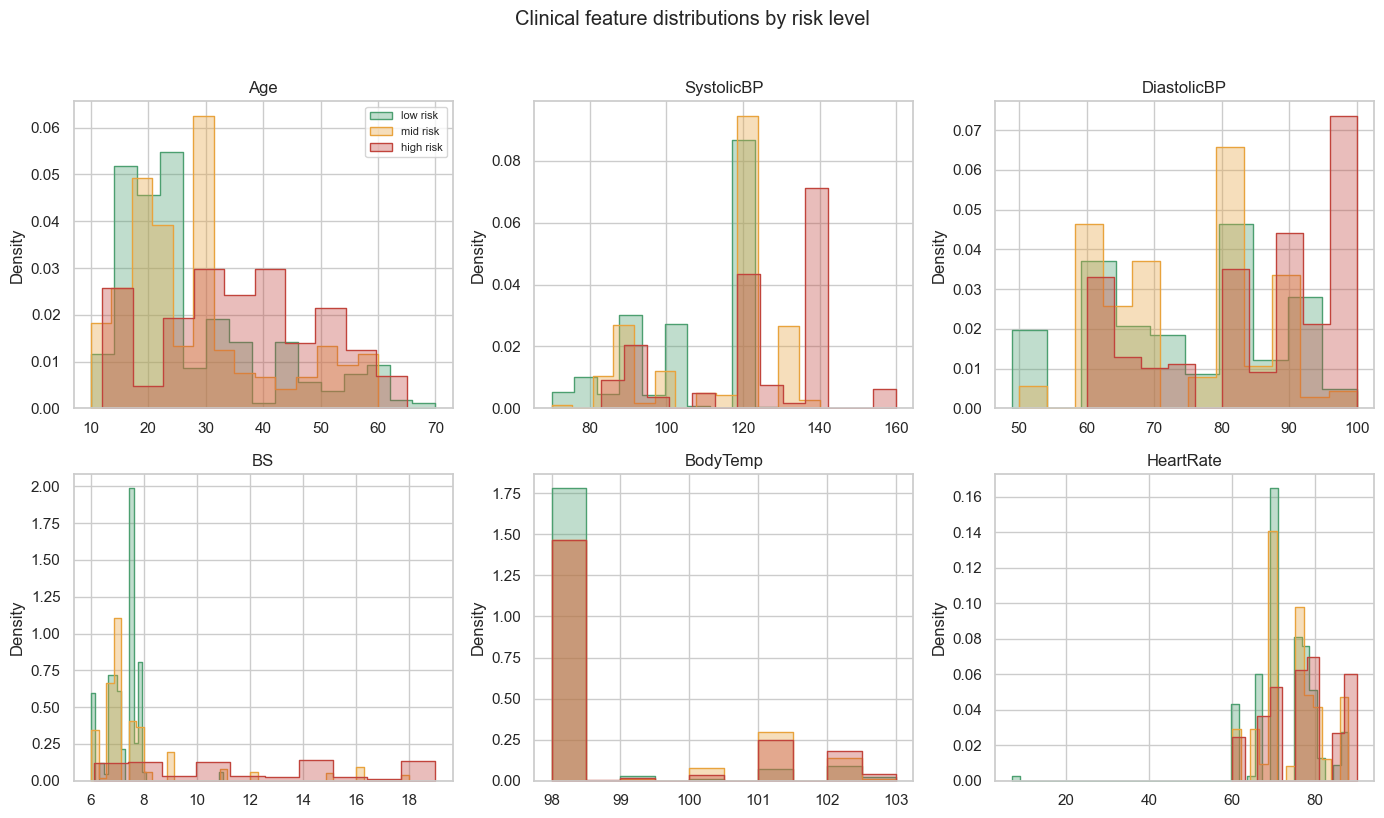

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.ravel(), FEATURES):
    for risk in RISK_ORDER:
        sns.histplot(
            df.loc[df[TARGET] == risk, feature], ax=ax, color=RISK_COLOR[risk],
            label=risk, stat="density", element="step", fill=True, alpha=0.35,
            common_norm=False,
        )
    ax.set_title(feature)
    ax.set_xlabel("")
axes.ravel()[0].legend(fontsize=8)
fig.suptitle("Clinical feature distributions by risk level", y=1.02)
plt.tight_layout()
plt.show()

**Histograms rather than boxplots, deliberately.** A boxplot compresses each group down to five numbers (min, quartiles, max) — it tells you the *typical range* per class but hides the *shape*: whether a distribution is unimodal, skewed, or has a sharp step at some threshold. That shape is exactly what matters for two things this notebook cares about:

1. **Model choice (Section 8).** How much the per-class histograms overlap vs. separate is a direct visual read on whether a *linear* boundary could ever separate the classes, or whether the boundary is a *threshold/step* — which is what a boxplot's five-number summary cannot show you. `BS` (blood sugar) in particular shows a step-like jump for `high risk` rather than a smoothly shifted bell curve — evidence for why tree-based models (which split on thresholds natively) end up outperforming distance- and margin-based models in Section 8.
2. **Clinical plausibility.** Real vital-sign risk cutoffs are literally threshold rules (e.g. a gestational-diabetes blood-sugar cutoff). A histogram can show that kind of step directly; a boxplot's quartiles would just shift slightly and hide it.

Density-normalised (not raw counts) since the three classes have different sample sizes (406 / 336 / 272) — without normalising, `low risk`'s taller bars would just reflect it having more rows, not a real distributional difference. Blood sugar (`BS`) and blood pressure (`SystolicBP`, `DiastolicBP`) show the clearest separation across risk levels, which is clinically expected. `BodyTemp` and `HeartRate` show far more overlap between classes, so they should contribute less — a prior to check the model against in Section 11 (feature importance).

## 6. Feature correlation

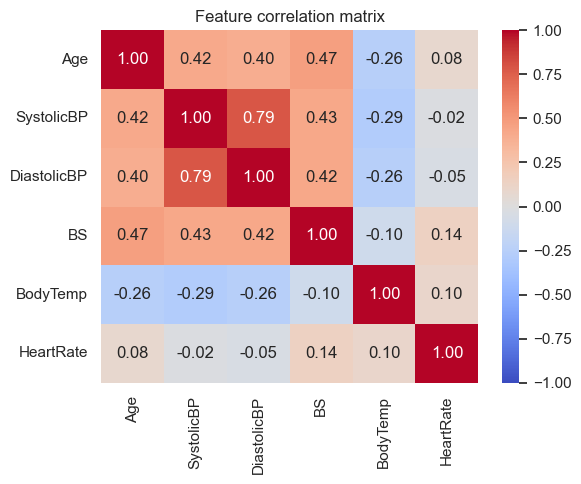

In [7]:
corr = df[FEATURES].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

`SystolicBP` and `DiastolicBP` are strongly correlated with each other (as expected physiologically), but no pair is so collinear that it would break a model. Tree-based models are inherently robust to this kind of redundancy, which is a small additional point in their favour over correlation-sensitive linear models.

## 7. Why a stratified train/test split?

`RiskLevel` is imbalanced (Section 3: ~40/33/27%). `train_test_split(..., stratify=y)` forces the train and test sets to preserve that same ratio. Without it, a single unlucky random split could under-represent `high risk` in the test set — the class where a missed detection is most costly — and make its recall estimate unreliable. The cell below demonstrates this directly: it draws 20 random 80/20 splits *without* stratification and compares the spread of the `high risk` test-set share against the single stratified split actually used for training.

Population 'high risk' share:            26.8%
Stratified split (random_state=42) share: 27.1%
20x unstratified splits: mean 27.6%, min 23.2%, max 31.5%


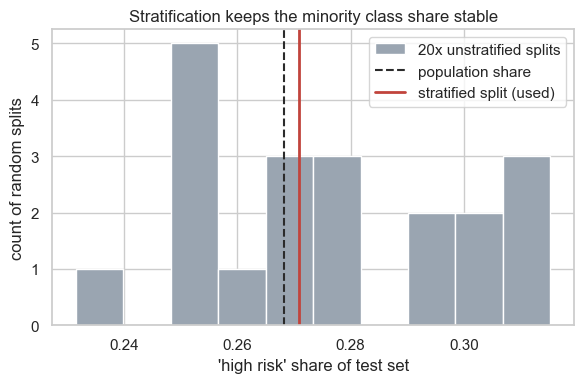

In [8]:
X, y = df[FEATURES], df[TARGET]

unstratified_shares = []
for seed in range(20):
    _, X_te, _, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    unstratified_shares.append((y_te == "high risk").mean())

_, X_te_strat, _, y_te_strat = split_data(df)
stratified_share = (y_te_strat == "high risk").mean()
population_share = (y == "high risk").mean()

print(f"Population 'high risk' share:            {population_share:.1%}")
print(f"Stratified split (random_state=42) share: {stratified_share:.1%}")
print(
    f"20x unstratified splits: mean {np.mean(unstratified_shares):.1%}, "
    f"min {np.min(unstratified_shares):.1%}, max {np.max(unstratified_shares):.1%}"
)

plt.figure(figsize=(6, 4))
plt.hist(unstratified_shares, bins=10, color="#9AA5B1", edgecolor="white",
         label="20x unstratified splits")
plt.axvline(population_share, color="#2B2B2B", linestyle="--", label="population share")
plt.axvline(stratified_share, color="#C1443C", linewidth=2, label="stratified split (used)")
plt.xlabel("'high risk' share of test set")
plt.ylabel("count of random splits")
plt.title("Stratification keeps the minority class share stable")
plt.legend()
plt.tight_layout()
plt.show()

The unstratified splits visibly wobble around the true 27% population share (with only ~270 high-risk rows to begin with, an 80/20 split has just ~55 in the test fold — small enough that luck-of-the-draw shifts the minority-class share noticeably). The stratified split pins it exactly, which is what makes the `high risk` recall figure reported later in this notebook trustworthy rather than a roll of the dice. All training and evaluation below therefore uses `split_data()` (stratified, `random_state=42`) for both the model comparison and the final held-out evaluation.

## 8. Model comparison: is Random Forest the right choice?

Rather than assume Random Forest is the best fit, six candidates spanning different underlying assumptions are cross-validated (5-fold stratified, on the training split only — the test set stays untouched until Section 10) and compared on accuracy and macro recall (the average of per-class recall, which does not let the majority `low risk` class hide a weak `high risk` recall). Logistic Regression is deliberately **not** included here: it is a fully valid multiclass classifier in scikit-learn (via a multinomial/softmax or one-vs-rest scheme, not limited to two classes) — but the team's call for this comparison was to spend the slots on models with more varied inductive biases instead:

- **Decision Tree** — a single tree, the building block Random Forest ensembles. Captures non-linear thresholds natively, but one tree tends to overfit its training split.
- **K-Nearest Neighbors** (scaled features) — classifies by the majority vote of the closest training points in feature space. No training phase, but assumes Euclidean distance across differently-scaled vitals is a meaningful notion of "similarity," which is a stretch here.
- **Naive Bayes** (Gaussian) — a fast probabilistic baseline. Assumes features are conditionally independent given the class and roughly Gaussian per class; Section 6 already shows `SystolicBP`/`DiastolicBP` are correlated, directly violating that independence assumption.
- **Support Vector Machine** (RBF kernel, scaled features) — finds a maximum-margin boundary in a non-linear kernel space. Powerful in general, but its margin/kernel geometry doesn't map naturally onto the axis-aligned threshold behaviour seen in Section 5's histograms (e.g. `BS`'s step-like jump).
- **Random Forest** — an ensemble of many trees trained on bootstrap samples and averaged. Captures non-linear thresholds and feature interactions (e.g. "high BP *and* high BS") without needing feature scaling, while the averaging reduces the overfitting a single Decision Tree is prone to.
- **Gradient Boosting** — also tree-based, but builds trees sequentially to correct prior errors rather than averaging independent trees. Can outperform Random Forest, but with more hyperparameters to get wrong and a higher risk of overfitting a dataset this size (~1,000 rows).

In [9]:
candidates = {
    "Decision Tree": DecisionTreeClassifier(random_state=RNG),
    "K-Nearest Neighbors": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Naive Bayes": GaussianNB(),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(random_state=RNG)),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RNG),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RNG),
}

rows = []
for name, est in candidates.items():
    scores = cross_validate(
        est, X_train, y_train, cv=cv,
        scoring=["accuracy", "recall_macro", "f1_macro"],
    )
    rows.append({
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_recall_macro": scores["test_recall_macro"].mean(),
        "cv_f1_macro": scores["test_f1_macro"].mean(),
    })

comparison_df = pd.DataFrame(rows).set_index("model").sort_values("cv_f1_macro", ascending=False)
comparison_df

,cv_accuracy,cv_recall_macro,cv_f1_macro
model,,,
Random Forest,0.815050,0.818736,0.819267
Decision Tree,0.797811,0.801108,0.801455
Gradient Boosting,0.787942,0.788536,0.791581
SVM (RBF),0.694213,0.687970,0.683036
K-Nearest Neighbors,0.670726,0.664888,0.666794
Naive Bayes,0.605438,0.587097,0.564748


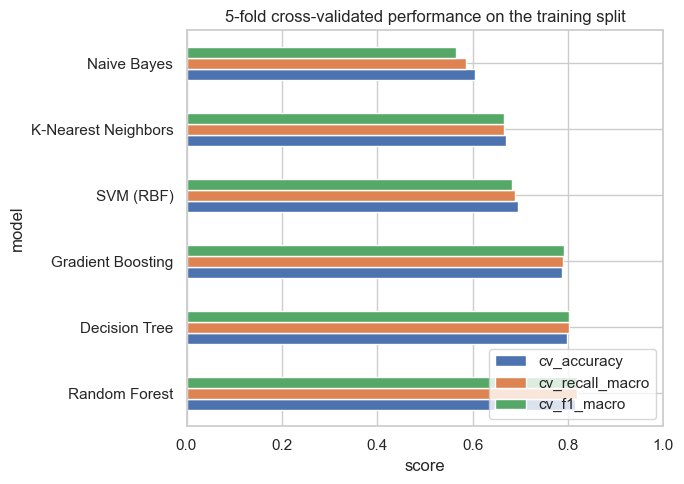

In [10]:
comparison_df.plot(kind="barh", figsize=(7, 5))
plt.title("5-fold cross-validated performance on the training split")
plt.xlabel("score")
plt.xlim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading the comparison — several converging reasons, not one:**

- **Random Forest wins outright** on cross-validated macro F1, and is the model tuned and shipped in Sections 9–10.
- **Decision Tree is the closest competitor**, which is itself informative: a single tree already captures most of the structure, confirming the boundary really is threshold-like (as Section 5's histograms suggested) rather than needing a smooth/linear model. Random Forest's edge over the single tree is exactly the variance reduction ensembling is supposed to buy.
- **Gradient Boosting trails Random Forest** here — plausible on a dataset this small, where sequential boosting has more opportunity to overfit than bagged averaging does.
- **SVM and KNN both underperform substantially**, despite feature scaling. Both rely on distance/margin geometry in the raw feature space; a threshold rule like "BS above X" is a single axis-aligned cut for a tree, but is a much less natural shape for a Euclidean-distance or kernel-margin boundary to learn.
- **Naive Bayes is the weakest by a wide margin** — its core independence assumption is directly violated by the `SystolicBP`/`DiastolicBP` correlation seen in Section 6, and clinical vitals are not well described by per-class Gaussians to begin with.

Every one of these is a distinct reason pointing the same direction, which is what makes Random Forest a well-supported choice here rather than a lucky pick.

## 9. Hyperparameter tuning (Random Forest)

The untuned Random Forest above uses reasonable defaults (`n_estimators=300`) but was never actually searched. A small grid search over the parameters most likely to matter — number of trees, tree depth, and leaf size (which controls overfitting) — checks whether tuning is worth the added complexity, still using only the training split.

In [11]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

start = time.time()
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RNG),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Search took {elapsed:.1f}s over {len(grid_search.cv_results_['params'])} candidates")
print(f"Best CV macro F1: {grid_search.best_score_:.3f} (untuned baseline: "
      f"{comparison_df.loc['Random Forest', 'cv_f1_macro']:.3f})")
print(f"Best params: {grid_search.best_params_}")

Search took 17.3s over 27 candidates
Best CV macro F1: 0.827 (untuned baseline: 0.819)
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}


If the tuned score is only marginally above the untuned baseline, that itself is a useful finding: it means the default `n_estimators=300` Random Forest is already close to this model family's ceiling on this dataset, and the added complexity of a tuned pipeline isn't earning its keep. The final model evaluated below is whichever of the two scores higher on cross-validation.

In [12]:
baseline_cv_f1 = comparison_df.loc["Random Forest", "cv_f1_macro"]
if grid_search.best_score_ > baseline_cv_f1:
    final_model = grid_search.best_estimator_
    print("Using tuned Random Forest as the final model.")
else:
    final_model = RandomForestClassifier(n_estimators=300, random_state=RNG).fit(X_train, y_train)
    print("Tuning did not beat the untuned default; using the default Random Forest "
          "(matches src/task1_risk_classifier.py) as the final model.")
final_model

Using tuned Random Forest as the final model.


,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 10. Final evaluation on the held-out test set

In [13]:
y_pred = final_model.predict(X_test)
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
).T
report_df

,precision,recall,f1-score,support
high risk,0.962963,0.945455,0.954128,55.000000
low risk,0.902778,0.802469,0.849673,81.000000
mid risk,0.753247,0.865672,0.805556,67.000000
accuracy,0.862069,0.862069,0.862069,0.862069
macro avg,0.872996,0.871198,0.869786,203.000000
weighted avg,0.869732,0.862069,0.863413,203.000000


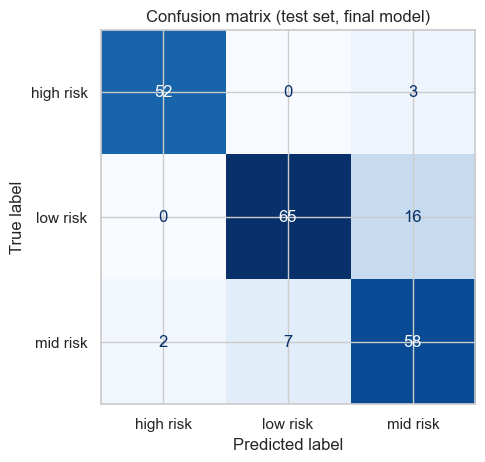

In [14]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred, labels=final_model.classes_),
    display_labels=final_model.classes_,
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set, final model)")
plt.tight_layout()
plt.show()

Recall on `high risk` (the costliest class to miss) is the number to watch — see the classification report above for the exact value on this run.

## 11. Feature importance

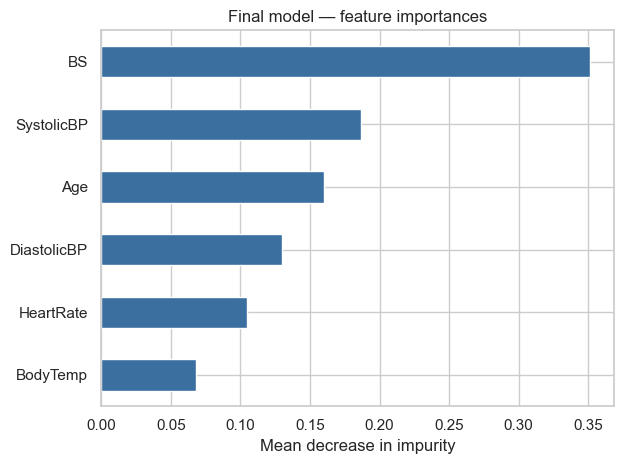

In [15]:
importances = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values()
ax = importances.plot(kind="barh", color="#3B6FA0")
ax.set_title("Final model — feature importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## 12. Summary & limitations

- **Class imbalance was checked, not assumed away:** Section 4 measures a mild ~1.5:1 imbalance ratio and empirically tests SMOTE; the improvement is within noise, so the production pipeline stays resampling-free by evidence, not convenience.
- **Model choice is evidence-based, from a wide field:** Section 8 cross-validates six models spanning distinct assumptions (a single tree, distance-based KNN, probabilistic Naive Bayes, margin-based SVM, and two tree ensembles). Random Forest wins, and every weaker model's shortfall traces to a specific, checkable reason (independence violated, distance geometry mismatch, single-tree variance) rather than one generic explanation.
- **Distributions were read as shapes, not summaries:** Section 5 uses histograms instead of boxplots specifically so threshold-like effects (e.g. `BS`) are visible — a boxplot's five-number summary would have hidden exactly the shape that explains why tree-based models win in Section 8.
- **Tuning was checked, not skipped:** Section 9 grid-searches the Random Forest's key hyperparameters; the final model is whichever of the tuned/untuned versions scores higher on cross-validation.
- **The train/test split is stratified deliberately** (Section 7), because with only ~270 high-risk rows an unlucky random split can distort exactly the metric — `high risk` recall — that matters most for this use case.
- Blood sugar and blood pressure readings drive most of the final model's predictive signal (Section 11), consistent with the EDA and clinical expectations.
- The model is a screening aid, not a diagnostic tool, and was trained on data from health facilities in Bangladesh — performance on a Kenyan population is not yet validated (see Task 2/3 in `PLAN.md`).
- Fairness/calibration across age groups is audited separately in Task 3, using the model artifact saved by `src/task1_risk_classifier.py` (which ships the untuned default Random Forest for simplicity/reproducibility; swap in the tuned parameters from Section 9 there if this notebook's search found a meaningfully better configuration).